In [1]:
import torch
import torch.nn as nn

In [95]:
class VAEModule(nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        self.n_out = n_out
        self.l1 = nn.Linear(n_in, n_hidden)
        self.mean = nn.Linear(n_hidden, n_out)
        self.log_var = nn.Linear(n_hidden, n_out)
        self.act = nn.Tanh()
        
    def forward(self, x):
        x = self.act(self.l1(x))
        mean = self.mean(x)
        log_var = self.log_var(x)
        z = mean + log_var.exp().sqrt() * torch.randn(self.n_out)
        return z

class VAE(nn.Module):
    def __init__(self, n_in, n_out, n_hidden, n_latent):
        super().__init__()
        self.n_in = n_in
        self.encode = VAEModule(n_in=n_in, n_hidden=n_hidden, n_out=n_latent)
        self.decode = VAEModule(n_in=n_latent, n_hidden=n_hidden, n_out=n_out)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        assert x.size(-1) == self.n_in
        z = self.encode(x)
        y = self.decode(z)
        return self.sigmoid(y)

In [97]:
model = VAE(n_in=784, n_out=784, n_hidden=500, n_latent=10)
model

VAE(
  (encode): VAEModule(
    (l1): Linear(in_features=784, out_features=500, bias=True)
    (mean): Linear(in_features=500, out_features=10, bias=True)
    (log_var): Linear(in_features=500, out_features=10, bias=True)
    (act): Tanh()
  )
  (decode): VAEModule(
    (l1): Linear(in_features=10, out_features=500, bias=True)
    (mean): Linear(in_features=500, out_features=784, bias=True)
    (log_var): Linear(in_features=500, out_features=784, bias=True)
    (act): Tanh()
  )
  (sigmoid): Sigmoid()
)

In [139]:
model.forward(torch.ones(1,784)).shape

torch.Size([1, 784])

In [124]:
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, ToTensor, Lambda
import os

In [104]:
from torch.optim import AdamW

In [130]:
PATH = os.getcwd()

flatten = Lambda(lambda x: x.view(-1))

transform = Compose([
    ToTensor(),
    flatten
])

mnist_train = MNIST(root=PATH, download=True, train=True, transform=transform)
mnist_test = MNIST(root=PATH, download=True, train=False, transform=transform)
train_dataloader = DataLoader(mnist_train, batch_size=100, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=100, shuffle=True)

In [131]:
loss_fn = nn.CrossEntropyLoss() # ? KL is integrated, right? Reconstruction loss?
model = VAE(n_in=784, n_out=784, n_hidden=500, n_latent=10)
opt = AdamW(model.parameters())
model.train()
for [imgs, _] in train_dataloader:
    opt.zero_grad()
    
    y_pred = model(imgs)
    loss = loss_fn(y_pred, imgs)
    loss.backward()
    opt.step()

In [132]:
model.eval()
img = model.decode(torch.randn(10))

In [137]:
from matplotlib.pyplot import imshow

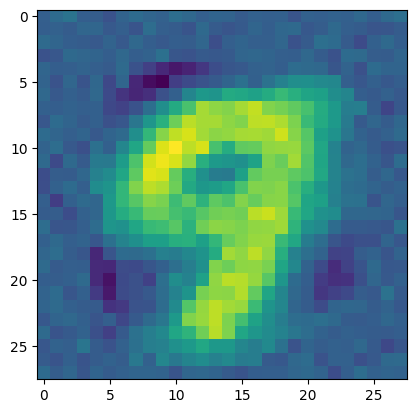

In [138]:
imshow(img.detach().numpy().reshape((28, 28)))